In [1]:
import numpy as np
import pandas as pd

np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [2]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [3]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [4]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [5]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [6]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [7]:
eigen_values

array([1.3536065 +0.j, 0.94557084+0.j, 0.77774573+0.j])

In [8]:
eigen_vectors

array([[-0.53875915+0.j, -0.69363291+0.j,  0.47813384+0.j],
       [-0.65608325+0.j, -0.01057596+0.j, -0.75461442+0.j],
       [-0.52848211+0.j,  0.72025103+0.j,  0.44938304+0.j]])

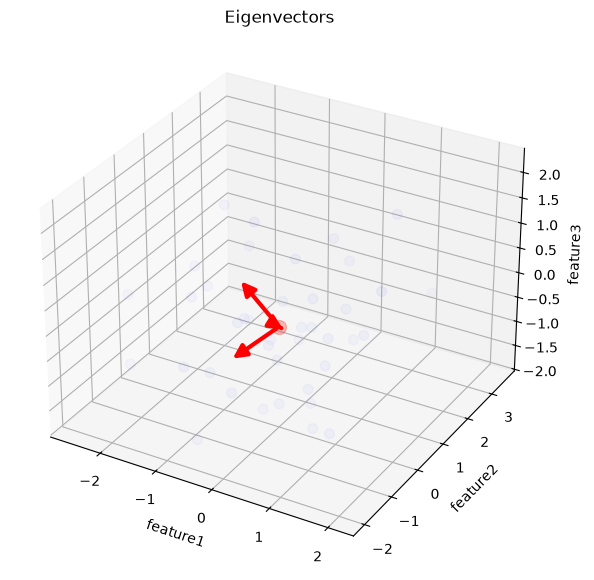

In [9]:
%matplotlib inline

from matplotlib import pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, _ = proj3d.proj_transform(
            xs3d, ys3d, zs3d, self.axes.get_proj()
        )
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d
        _, _, projected_zs = proj3d.proj_transform(
            xs3d, ys3d, zs3d, self.axes.get_proj()
        )
        return min(projected_zs)


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

features = df[["feature1", "feature2", "feature3"]]
center = features.mean().to_numpy()

ax.scatter(
    features["feature1"],
    features["feature2"],
    features["feature3"],
    s=50,
    color="blue",
    alpha=0.2
)

ax.scatter(*center, s=100, color="red", alpha=0.5)

for vector in np.real(eigen_vectors.T):
    arrow = Arrow3D(
        [center[0], center[0] + vector[0]],
        [center[1], center[1] + vector[1]],
        [center[2], center[2] + vector[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="r"
    )
    ax.add_artist(arrow)

ax.set_xlabel("feature1")
ax.set_ylabel("feature2")
ax.set_zlabel("feature3")
ax.set_title("Eigenvectors")

plt.show()

In [10]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915+0.j, -0.69363291+0.j,  0.47813384+0.j],
       [-0.65608325+0.j, -0.01057596+0.j, -0.75461442+0.j]])

In [11]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433+0.000000j,1.795862+0.000000j,1
1,1.056919+0.000000j,-0.212737+0.000000j,0
2,-0.271876+0.000000j,0.498222+0.000000j,1
3,-0.621586+0.000000j,0.023110+0.000000j,1
4,1.567286+0.000000j,1.730967+0.000000j,1


In [15]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
for trace in fig.data:
    trace.x = np.real(np.asarray(trace.x)).astype(float)
    trace.y = np.real(np.asarray(trace.y)).astype(float)

for trace in fig.data:
    trace.x = [float(np.real(value)) for value in trace.x]
    trace.y = [float(np.real(value)) for value in trace.y]

# Convert PCA components to real floating-point values before creating the figure
plot_df = new_df.copy()
plot_df["PC1"] = np.real(plot_df["PC1"]).astype(float)
plot_df["PC2"] = np.real(plot_df["PC2"]).astype(float)

fig = px.scatter(
    plot_df,
    x="PC1",
    y="PC2",
    color="target",
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.update_traces(
    marker=dict(
        size=12,
        line=dict(width=2, color="DarkSlateGrey")
    )
)

fig.show()